<a href="https://colab.research.google.com/github/nietbaeviysa/Karakalpak-NLP/blob/main/notebooks/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Подключаем Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

# Загружаем наши файлы
vocab = pd.read_csv('/content/drive/MyDrive/Karakalpak-NLP/karakalpak_vocabulary.csv')
sentiment = pd.read_csv('/content/drive/MyDrive/Karakalpak-NLP/karakalpak_sentiment_corrected.csv')

print(f"Словарь: {len(vocab)} слов")
print(f"Sentiment lexicon: {len(sentiment)} слов")
print("\nПервые 5 строк sentiment:")
print(sentiment.head())

Mounted at /content/drive
Словарь: 17293 слов
Sentiment lexicon: 17290 слов

Первые 5 строк sentiment:
         word  frequency         source sentiment confidence
0  қарақалпақ       1016  dastan_corpus   neutral        low
1         деп        978  dastan_corpus   neutral       high
2         бир        835  dastan_corpus   neutral       high
3      қоблан        804  dastan_corpus   neutral        low
4       халық        718  dastan_corpus  positive       high


In [7]:
!pip install pdfplumber -q

# Загружаем тексты дастанов
import pdfplumber

base = '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 68.8 MB/s eta 0:00:00


In [9]:
# Загружаем тексты дастанов
import pdfplumber

base = '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/'

texts = {}

with open(base + 'kyrk_kyz.txt', 'r', encoding='utf-8') as f:
    texts['Qiriq Qiz'] = f.read()

with pdfplumber.open(base + 'kitapxana.com_qoblan.pdf') as pdf:
    text = ""
    for page in pdf.pages:
        text += page.extract_text() or ""
    texts['Qoblan'] = text

with pdfplumber.open(base + 'kitapxana.com_er-ziywar-qurbanbek.pdf') as pdf:
    text = ""
    for page in pdf.pages:
        text += page.extract_text() or ""
    texts['Er Ziyar'] = text

# Создаём словарь тональности
sentiment_dict = {}
for _, row in sentiment.iterrows():
    sentiment_dict[row['word']] = row['sentiment']

# Анализируем каждый дастан
results = {}
for name, text in texts.items():
    words = text.lower().split()
    words = [w.strip('.,!?;:»«*#') for w in words]

    pos, neg, neu = 0, 0, 0
    for word in words:
        s = sentiment_dict.get(word, 'neutral')
        if s == 'positive': pos += 1
        elif s == 'negative': neg += 1
        else: neu += 1

    total = pos + neg + neu
    results[name] = {
        'positive': round(pos/total*100, 2),
        'negative': round(neg/total*100, 2),
        'neutral': round(neu/total*100, 2),
        'total_words': total
    }
    print(f"\n{name}:")
    print(f"  Позитивные: {pos/total*100:.1f}%")
    print(f"  Негативные: {neg/total*100:.1f}%")
    print(f"  Всего слов: {total}")


Qiriq Qiz:
  Позитивные: 2.9%
  Негативные: 0.9%
  Всего слов: 2376

Qoblan:
  Позитивные: 2.6%
  Негативные: 1.2%
  Всего слов: 42471

Er Ziyar:
  Позитивные: 2.4%
  Негативные: 1.3%
  Всего слов: 45751


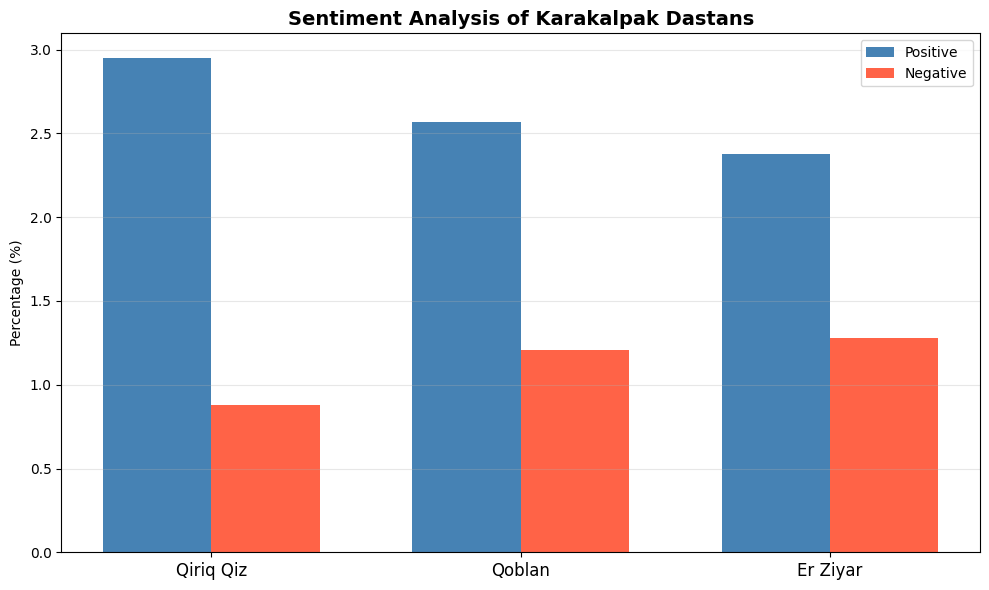

Graph saved!


In [10]:
import numpy as np

dastans = list(results.keys())
pos_vals = [results[d]['positive'] for d in dastans]
neg_vals = [results[d]['negative'] for d in dastans]

x = np.arange(len(dastans))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, pos_vals, width, label='Positive', color='steelblue')
bars2 = ax.bar(x + width/2, neg_vals, width, label='Negative', color='tomato')

ax.set_title('Sentiment Analysis of Karakalpak Dastans', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(dastans, fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Karakalpak-NLP/sentiment_analysis.png', dpi=150)
plt.show()

print("Graph saved!")